# KOSPI 시계열 데이터 EDA
**목표**: 수집된 KOSPI 종목 데이터의 품질 검증, 분포 분석, 기술적 지표 확인, 학습 데이터 필터링 기준 도출

## 0. 환경 설정

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'AppleGothic'   # macOS 한글 폰트
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

DATA_DIR = Path('data/stocks')
print(f'수집된 parquet 파일 수: {len(list(DATA_DIR.glob("*.parquet")))}')

/Users/seungbin/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


수집된 parquet 파일 수: 837


## 1. 데이터 로딩 & 기본 현황

In [2]:
# 전체 종목 로드 (메타 정보만 먼저)
meta_rows = []
for fp in sorted(DATA_DIR.glob('*.parquet')):
    df = pd.read_parquet(fp)
    meta_rows.append({
        '종목코드': df['종목코드'].iloc[0],
        '종목명':  df['종목명'].iloc[0],
        '업종':    df['업종'].iloc[0],
        '행수':    len(df),
        '시작일':  df['Date'].min(),
        '종료일':  df['Date'].max(),
        '기간_영업일': len(df),
        'Volume_0_비율': (df['Volume'] == 0).mean(),
        'Close_결측비율': df['Close'].isna().mean(),
    })

meta = pd.DataFrame(meta_rows)
print(f'총 종목 수: {len(meta)}')
meta.head(10)

총 종목 수: 837


,종목코드,종목명,업종,행수,시작일,종료일,기간_영업일,Volume_0_비율,Close_결측비율
0,000020,동화약품,의약품 제조업,1552,2020-01-02,2026-05-04,1552,0.009665,0.0
1,000040,KR모터스,그외 기타 운송장비 제조업,1552,2020-01-02,2026-05-04,1552,0.023840,0.0
2,000050,경방,종합 소매업,1552,2020-01-02,2026-05-04,1552,0.006443,0.0
3,000070,삼양홀딩스,기타 금융업,1552,2020-01-02,2026-05-04,1552,0.019330,0.0
4,000080,하이트진로,알코올음료 제조업,1552,2020-01-02,2026-05-04,1552,0.008376,0.0
5,000100,유한양행,의약품 제조업,1552,2020-01-02,2026-05-04,1552,0.012887,0.0
6,000120,CJ대한통운,도로 화물 운송업,1552,2020-01-02,2026-05-04,1552,0.010309,0.0
7,000140,하이트진로홀딩스,기타 금융업,1552,2020-01-02,2026-05-04,1552,0.008376,0.0
8,000150,두산,기타 금융업,1552,2020-01-02,2026-05-04,1552,0.010309,0.0
9,000180,성창기업지주,회사 본부 및 경영 컨설팅 서비스업,1552,2020-01-02,2026-05-04,1552,0.017397,0.0


In [3]:
# 업종 분포
sector_counts = meta['업종'].value_counts()
print(f'업종 수: {len(sector_counts)}')
print(sector_counts.head(20))

업종 수: 129
업종
기타 금융업                      67
자동차 신품 부품 제조업               46
의약품 제조업                     42
1차 철강 제조업                   38
기타 화학제품 제조업                 33
기초 화학물질 제조업                 28
부동산 임대 및 공급업                26
전자부품 제조업                    22
금융 지원 서비스업                  19
특수 목적용 기계 제조업               18
플라스틱제품 제조업                  17
봉제의복 제조업                    16
기타 식품 제조업                   15
종합 소매업                      13
일반 목적용 기계 제조업               13
토목 건설업                      13
1차 비철금속 제조업                 12
보험업                         11
기타 전문 도매업                   11
시멘트, 석회, 플라스터 및 그 제품 제조업    11
Name: count, dtype: int64


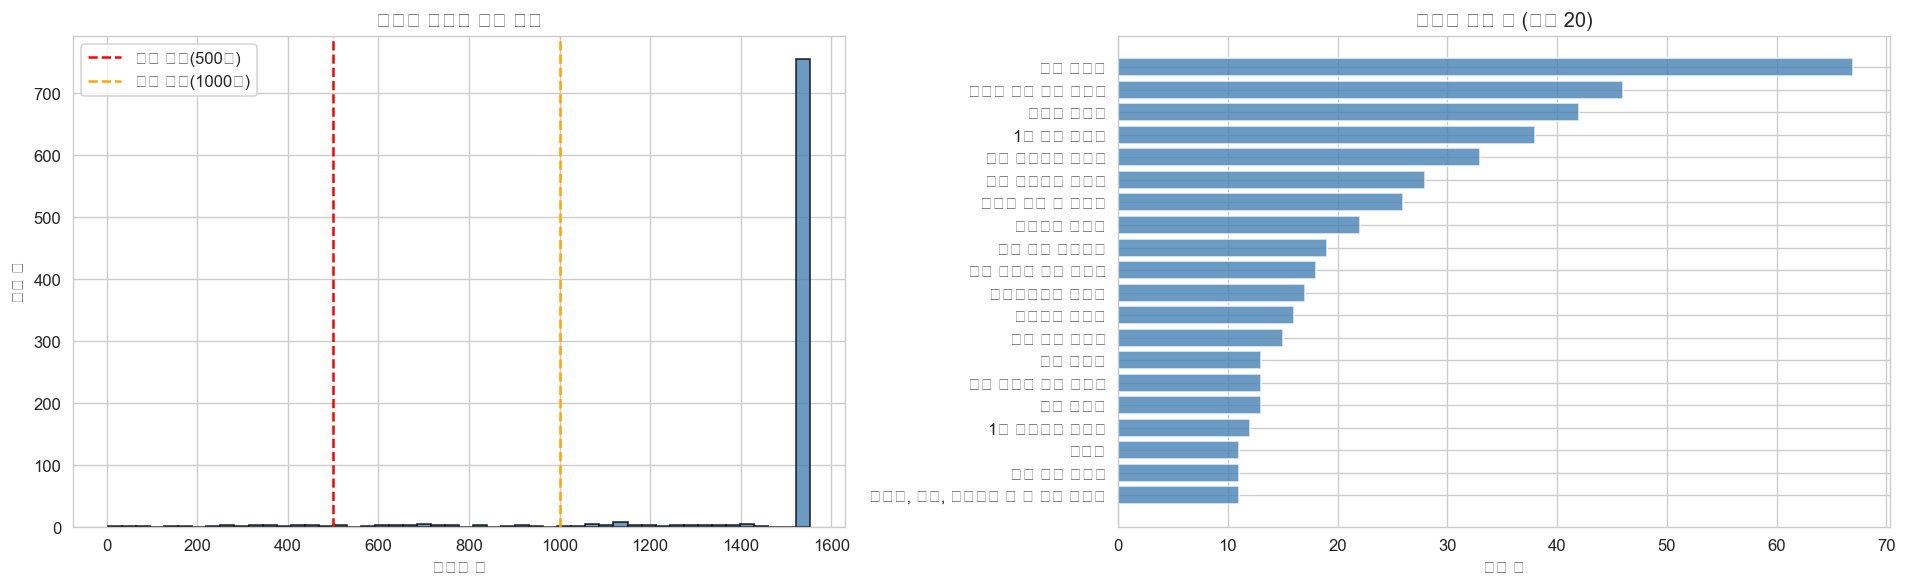

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 데이터 길이(영업일) 분포
axes[0].hist(meta['행수'], bins=50, edgecolor='k', color='steelblue', alpha=0.8)
axes[0].axvline(500, color='red', linestyle='--', label='필터 후보(500일)')
axes[0].axvline(1000, color='orange', linestyle='--', label='필터 후보(1000일)')
axes[0].set_xlabel('영업일 수')
axes[0].set_ylabel('종목 수')
axes[0].set_title('종목별 데이터 길이 분포')
axes[0].legend()

# 상위 20 업종 막대
top20 = sector_counts.head(20)
axes[1].barh(top20.index[::-1], top20.values[::-1], color='steelblue', alpha=0.8)
axes[1].set_xlabel('종목 수')
axes[1].set_title('업종별 종목 수 (상위 20)')

plt.tight_layout()
plt.show()

In [5]:
# 데이터 길이 구간별 종목 수
bins = [0, 250, 500, 1000, 1200, 1400, 9999]
labels = ['<1년', '1~2년', '2~4년', '4~5년', '5~6년', '>6년']
meta['길이구간'] = pd.cut(meta['행수'], bins=bins, labels=labels)
print(meta['길이구간'].value_counts().sort_index())

길이구간
<1년       6
1~2년     14
2~4년     23
4~5년     18
5~6년     15
>6년     761
Name: count, dtype: int64


## 2. 데이터 품질 검증

In [6]:
# 전체 데이터 로드 (분석용)
all_dfs = [pd.read_parquet(fp) for fp in sorted(DATA_DIR.glob('*.parquet'))]
df_all = pd.concat(all_dfs, ignore_index=True)
df_all['Date'] = pd.to_datetime(df_all['Date'])
print(f'전체 행수: {len(df_all):,}')
print(f'종목 수: {df_all["종목코드"].nunique()}')
print(f'날짜 범위: {df_all["Date"].min().date()} ~ {df_all["Date"].max().date()}')

전체 행수: 1,242,071
종목 수: 837
날짜 범위: 2020-01-02 ~ 2026-05-04


In [7]:
# 컬럼별 결측 비율
missing = df_all.isnull().mean().sort_values(ascending=False)
missing_pct = (missing * 100).round(2)
print('결측값 비율 (상위 15):')
print(missing_pct[missing_pct > 0].head(15))

결측값 비율 (상위 15):
SMA_120           8.00
SMA_60            3.97
Volume_ratio      2.37
RSI_14            2.11
Volatility_20d    1.35
Return_20d        1.35
BB_upper          1.28
BB_width          1.28
BB_lower          1.28
Volume_MA20       1.28
SMA_20            1.28
ATR_14            0.88
SMA_10            0.61
Return_5d         0.34
SMA_5             0.27
dtype: float64


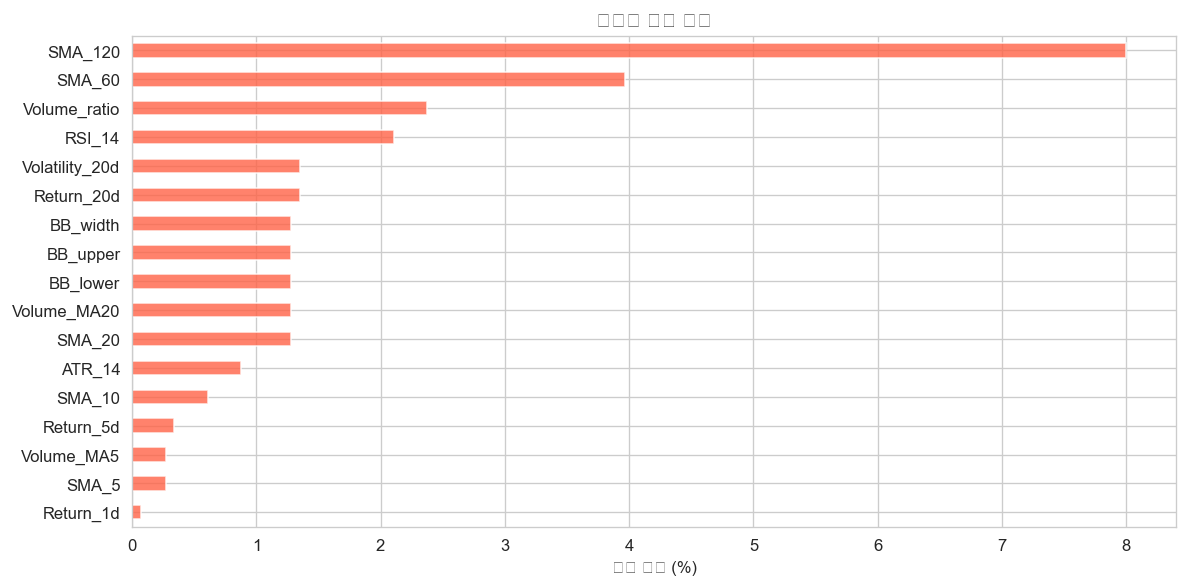

In [8]:
# 결측 비율 시각화
missing_nonzero = missing_pct[missing_pct > 0]
if len(missing_nonzero) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    missing_nonzero.sort_values().plot(kind='barh', ax=ax, color='tomato', alpha=0.8)
    ax.set_xlabel('결측 비율 (%)')
    ax.set_title('컬럼별 결측 비율')
    plt.tight_layout()
    plt.show()
else:
    print('결측값 없음')

거래량=0인 날이 있는 종목: 792
거래량=0 비율 > 10% 종목: 36


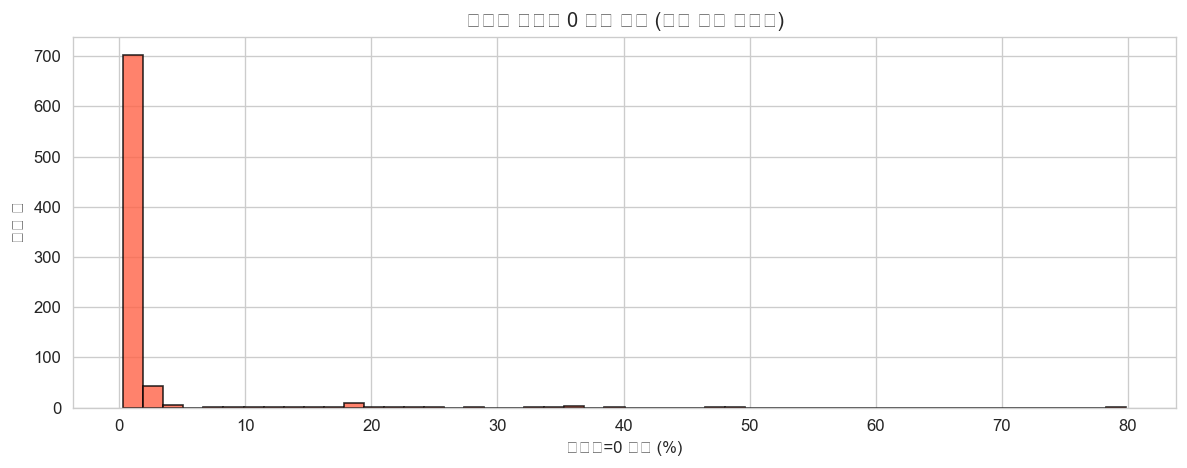

In [9]:
# 거래량 0인 날 비율 분포 (거래정지 / 투자유의 종목 감지)
vol0 = meta['Volume_0_비율']
print(f'거래량=0인 날이 있는 종목: {(vol0 > 0).sum()}')
print(f'거래량=0 비율 > 10% 종목: {(vol0 > 0.1).sum()}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(vol0[vol0 > 0] * 100, bins=50, edgecolor='k', color='tomato', alpha=0.8)
ax.set_xlabel('거래량=0 비율 (%)')
ax.set_ylabel('종목 수')
ax.set_title('종목별 거래량 0 비율 분포 (거래 있는 종목만)')
plt.tight_layout()
plt.show()

In [10]:
# 이상치 탐지: 일간 수익률 극단값 (|return| > 30%)
extreme_ret = df_all[df_all['Return_1d'].abs() > 0.30][['Date', '종목코드', '종목명', 'Return_1d', 'Close', 'Volume']]
print(f'|일간수익률| > 30% 레코드 수: {len(extreme_ret)}')
print(extreme_ret.nlargest(10, 'Return_1d')[['Date','종목명','Return_1d','Volume']].to_string())

|일간수익률| > 30% 레코드 수: 301
             Date       종목명  Return_1d  Volume
260731 2026-04-27    SG세계물산   9.000000       0
273147 2026-04-27        남성   9.000000       0
754880 2026-04-27  아이티센씨티에스   9.000000       0
890527 2025-11-17     이엔플러스   9.000000       0
445383 2026-03-03       윌비스   8.740741  104906
24443  2024-09-24    DH오토넥스   8.009009       0
24519  2025-01-16    DH오토넥스   8.000900       0
24581  2025-04-21    DH오토넥스   8.000900       0
24702  2025-10-23    DH오토넥스   7.992806       0
385944 2024-04-03       카프로   4.000000       0


## 3. 수익률 & 변동성 분포 분석

평균: 0.0007
표준편차: 0.0394
왜도: 79.3712
첨도: 16622.0867


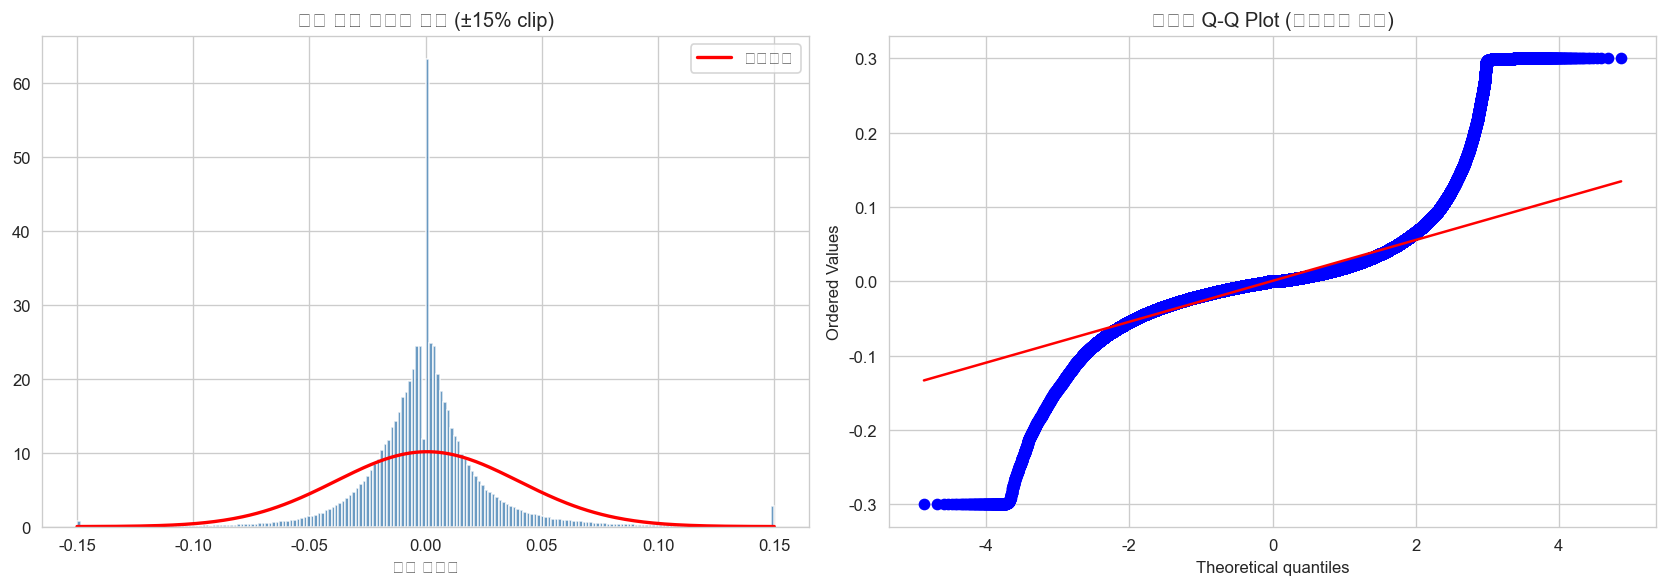

In [11]:
# 전체 일간 수익률 분포
ret = df_all['Return_1d'].dropna()
print(f'평균: {ret.mean():.4f}')
print(f'표준편차: {ret.std():.4f}')
print(f'왜도: {ret.skew():.4f}')
print(f'첨도: {ret.kurt():.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 수익률 히스토그램
ret_clip = ret.clip(-0.15, 0.15)
axes[0].hist(ret_clip, bins=200, color='steelblue', alpha=0.8, density=True)
x = np.linspace(-0.15, 0.15, 300)
from scipy import stats
mu, sigma = ret.mean(), ret.std()
axes[0].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', lw=2, label='정규분포')
axes[0].set_xlabel('일간 수익률')
axes[0].set_title('전체 일간 수익률 분포 (±15% clip)')
axes[0].legend()

# Q-Q plot
stats.probplot(ret.clip(-0.30, 0.30), dist='norm', plot=axes[1])
axes[1].set_title('수익률 Q-Q Plot (정규분포 비교)')

plt.tight_layout()
plt.show()

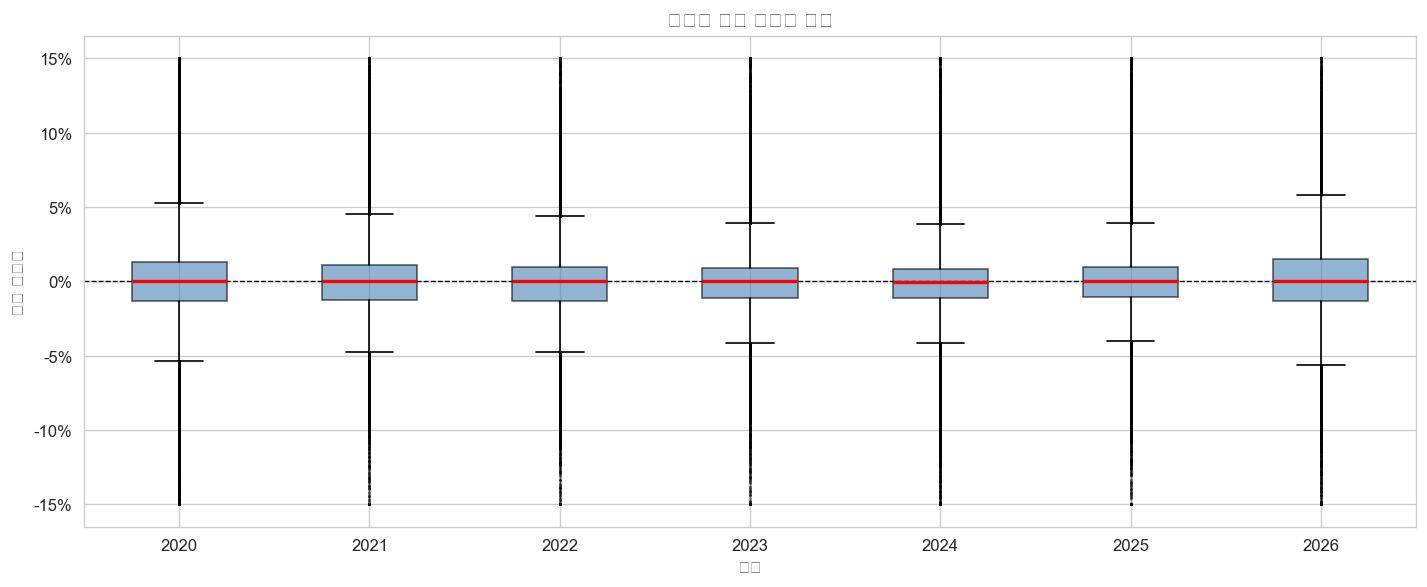

In [12]:
# 연도별 수익률 분포 박스플롯
df_all['연도'] = df_all['Date'].dt.year

fig, ax = plt.subplots(figsize=(12, 5))
years = sorted(df_all['연도'].unique())
data_by_year = [df_all[df_all['연도'] == y]['Return_1d'].dropna().clip(-0.15, 0.15).values for y in years]
bp = ax.boxplot(data_by_year, labels=years, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='red', lw=2),
                flierprops=dict(marker='.', markersize=1, alpha=0.3))
ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.set_xlabel('연도')
ax.set_ylabel('일간 수익률')
ax.set_title('연도별 일간 수익률 분포')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
plt.tight_layout()
plt.show()

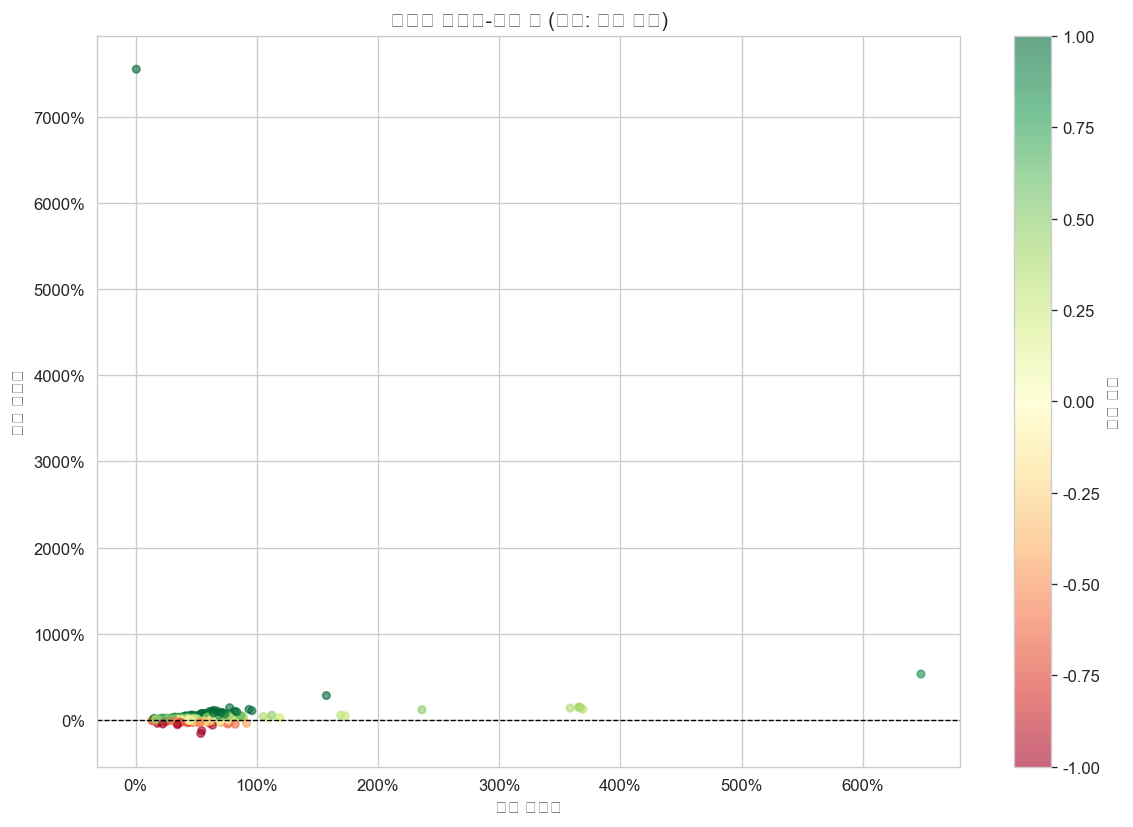

연간 수익률 분포:
count    837.000000
mean       0.254415
std        2.625011
min       -1.577153
25%        0.022276
50%        0.122122
75%        0.245190
max       75.525444
Name: ann_return, dtype: float64


In [13]:
# 종목별 평균 연간 수익률 및 변동성 (리스크-리턴 맵)
stats_per_stock = df_all.groupby('종목코드').agg(
    ann_return=('Return_1d', lambda x: x.mean() * 252),
    ann_vol=('Return_1d', lambda x: x.std() * np.sqrt(252)),
    sharpe=('Return_1d', lambda x: (x.mean() / x.std()) * np.sqrt(252) if x.std() > 0 else np.nan),
    n_days=('Return_1d', 'count'),
).reset_index()

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(
    stats_per_stock['ann_vol'],
    stats_per_stock['ann_return'],
    c=stats_per_stock['sharpe'],
    cmap='RdYlGn', alpha=0.6, s=20,
    vmin=-1, vmax=1
)
plt.colorbar(sc, label='샤프 지수')
ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.set_xlabel('연간 변동성')
ax.set_ylabel('연간 수익률')
ax.set_title('종목별 리스크-리턴 맵 (색상: 샤프 지수)')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
plt.tight_layout()
plt.show()

print('연간 수익률 분포:')
print(stats_per_stock['ann_return'].describe())

## 4. 섹터별 분석

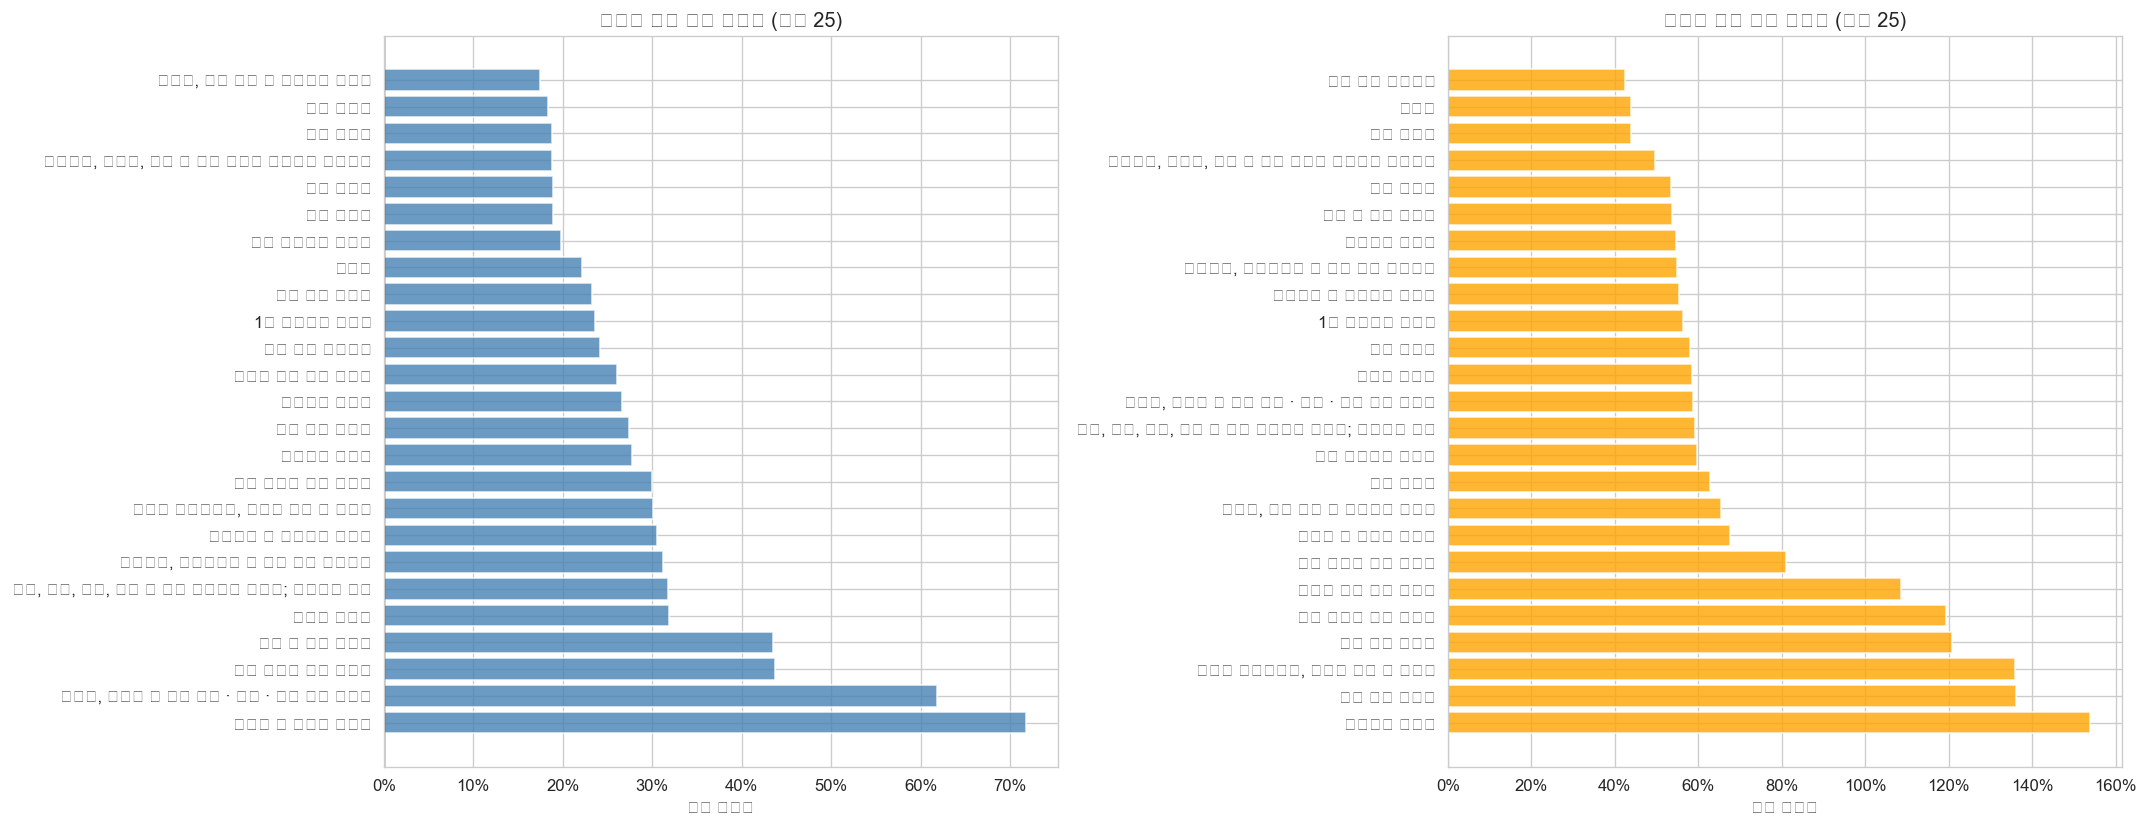

In [14]:
# 업종별 평균 수익률 & 변동성
sector_stats = df_all.groupby('업종').agg(
    ann_return=('Return_1d', lambda x: x.mean() * 252),
    ann_vol=('Return_1d', lambda x: x.std() * np.sqrt(252)),
    종목수=('종목코드', 'nunique'),
).reset_index().sort_values('ann_return', ascending=False)

# 종목 수 10개 이상 업종만
sector_stats = sector_stats[sector_stats['종목수'] >= 5].head(25)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

colors_ret = ['tomato' if v < 0 else 'steelblue' for v in sector_stats['ann_return']]
axes[0].barh(sector_stats['업종'], sector_stats['ann_return'], color=colors_ret, alpha=0.8)
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_xlabel('연간 수익률')
axes[0].set_title('업종별 평균 연간 수익률 (상위 25)')
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))

sector_stats_vol = sector_stats.sort_values('ann_vol', ascending=False)
axes[1].barh(sector_stats_vol['업종'], sector_stats_vol['ann_vol'], color='orange', alpha=0.8)
axes[1].set_xlabel('연간 변동성')
axes[1].set_title('업종별 평균 연간 변동성 (상위 25)')
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))

plt.tight_layout()
plt.show()

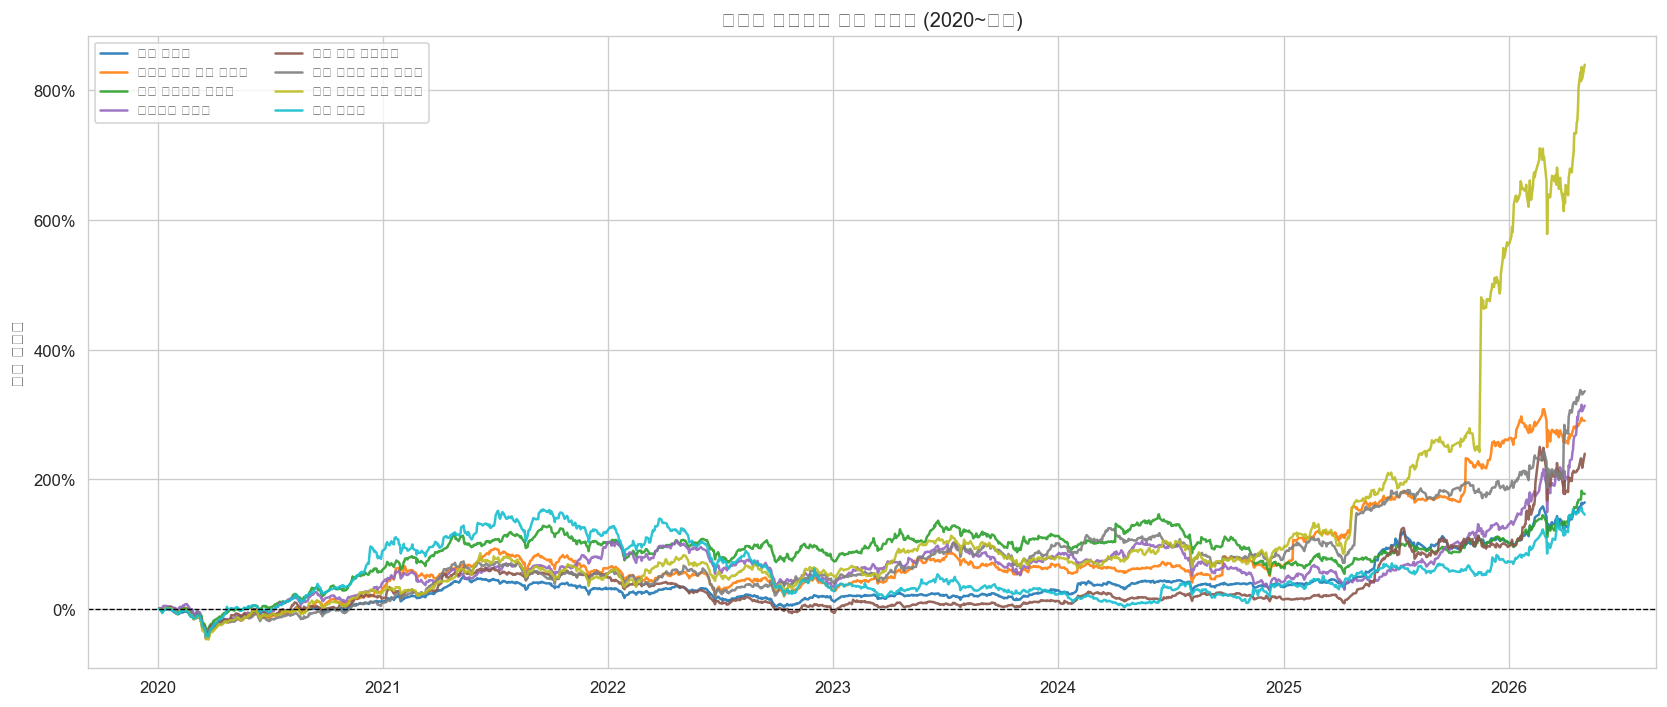

In [15]:
# 업종별 누적 수익률 (섹터 지수 proxy)
# 데이터 충분한 상위 8개 업종
top_sectors = sector_stats.nlargest(8, '종목수')['업종'].tolist()

# 2020-01-01 이후, 데이터 있는 종목만
df_2020 = df_all[df_all['Date'] >= '2020-01-01'].copy()

fig, ax = plt.subplots(figsize=(14, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(top_sectors)))

for sector, color in zip(top_sectors, colors):
    sector_df = df_2020[df_2020['업종'] == sector]
    daily_avg = sector_df.groupby('Date')['Return_1d'].mean()
    cumret = (1 + daily_avg).cumprod() - 1
    ax.plot(cumret.index, cumret.values, label=sector[:15], color=color, lw=1.5, alpha=0.9)

ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.set_ylabel('누적 수익률')
ax.set_title('업종별 동일가중 누적 수익률 (2020~현재)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.legend(loc='upper left', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

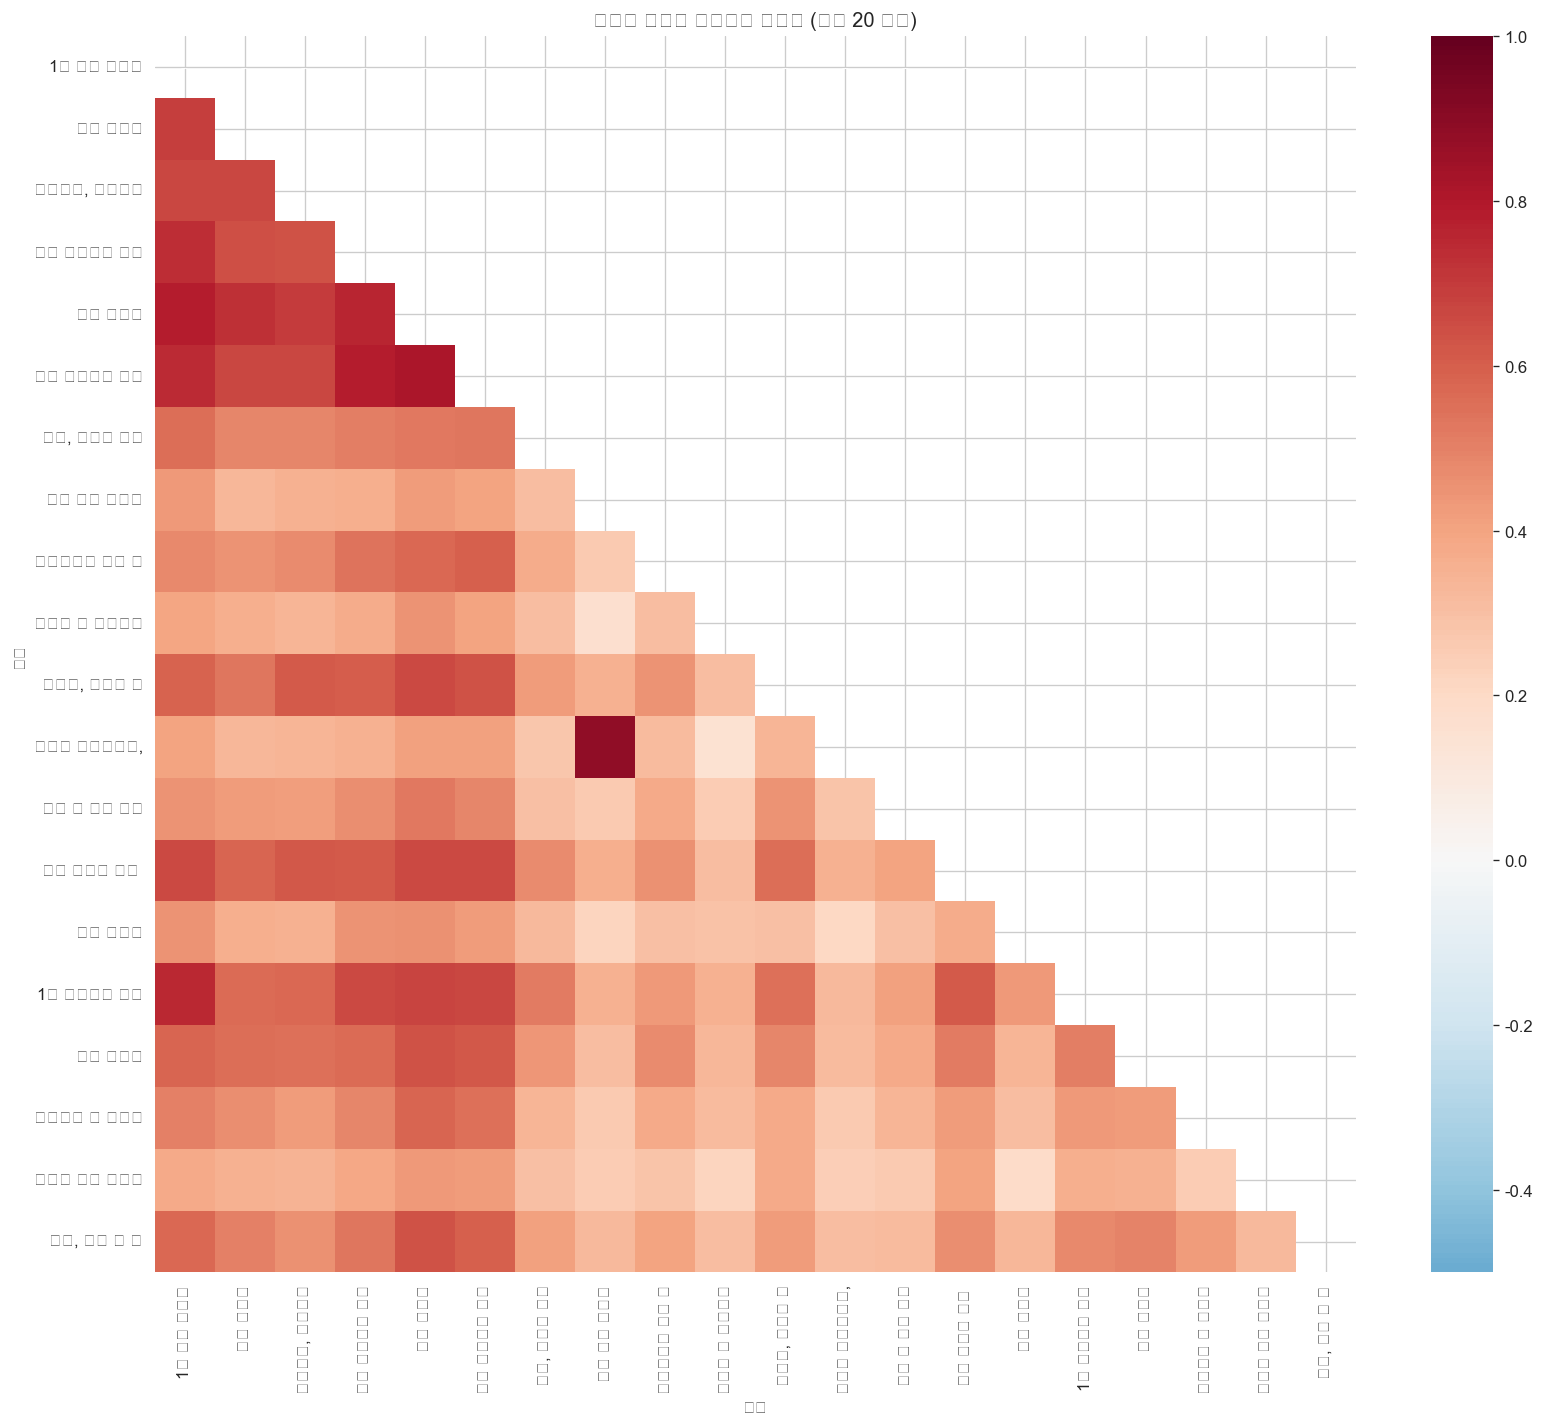

In [16]:
# 업종 간 수익률 상관관계 히트맵
pivot = df_2020.pivot_table(index='Date', columns='업종', values='Return_1d', aggfunc='mean')
# 결측 많은 컬럼 제거
pivot = pivot.dropna(thresh=int(len(pivot) * 0.5), axis=1)
corr = pivot.corr()

# 상위 20 업종만
top20_sectors = pivot.count().nlargest(20).index
corr_top = corr.loc[top20_sectors, top20_sectors]

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_top, dtype=bool))
sns.heatmap(
    corr_top, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-0.5, vmax=1,
    ax=ax, annot_kws={'size': 7},
    xticklabels=[s[:10] for s in corr_top.columns],
    yticklabels=[s[:10] for s in corr_top.index]
)
ax.set_title('업종별 수익률 상관관계 히트맵 (상위 20 업종)')
plt.tight_layout()
plt.show()

## 5. 기술적 지표 시각화

In [17]:
# 대표 종목 샘플: 삼성전자(005930) — 데이터 길이 기준 상위 종목으로 선택
sample_code = '005930'  # 삼성전자
fp = DATA_DIR / f'{sample_code}.parquet'

if fp.exists():
    df_s = pd.read_parquet(fp)
    df_s['Date'] = pd.to_datetime(df_s['Date'])
else:
    # 데이터 길이 가장 긴 종목 자동 선택
    sample_code = meta.nlargest(1, '행수')['종목코드'].iloc[0]
    df_s = pd.read_parquet(DATA_DIR / f'{sample_code}.parquet')
    df_s['Date'] = pd.to_datetime(df_s['Date'])

# 최근 2년만 시각화
df_plot = df_s[df_s['Date'] >= '2023-01-01'].copy()
print(f'종목: {df_s["종목명"].iloc[0]} ({sample_code}), 플롯 기간: {len(df_plot)}일')

종목: 삼성전자 (005930), 플롯 기간: 812일


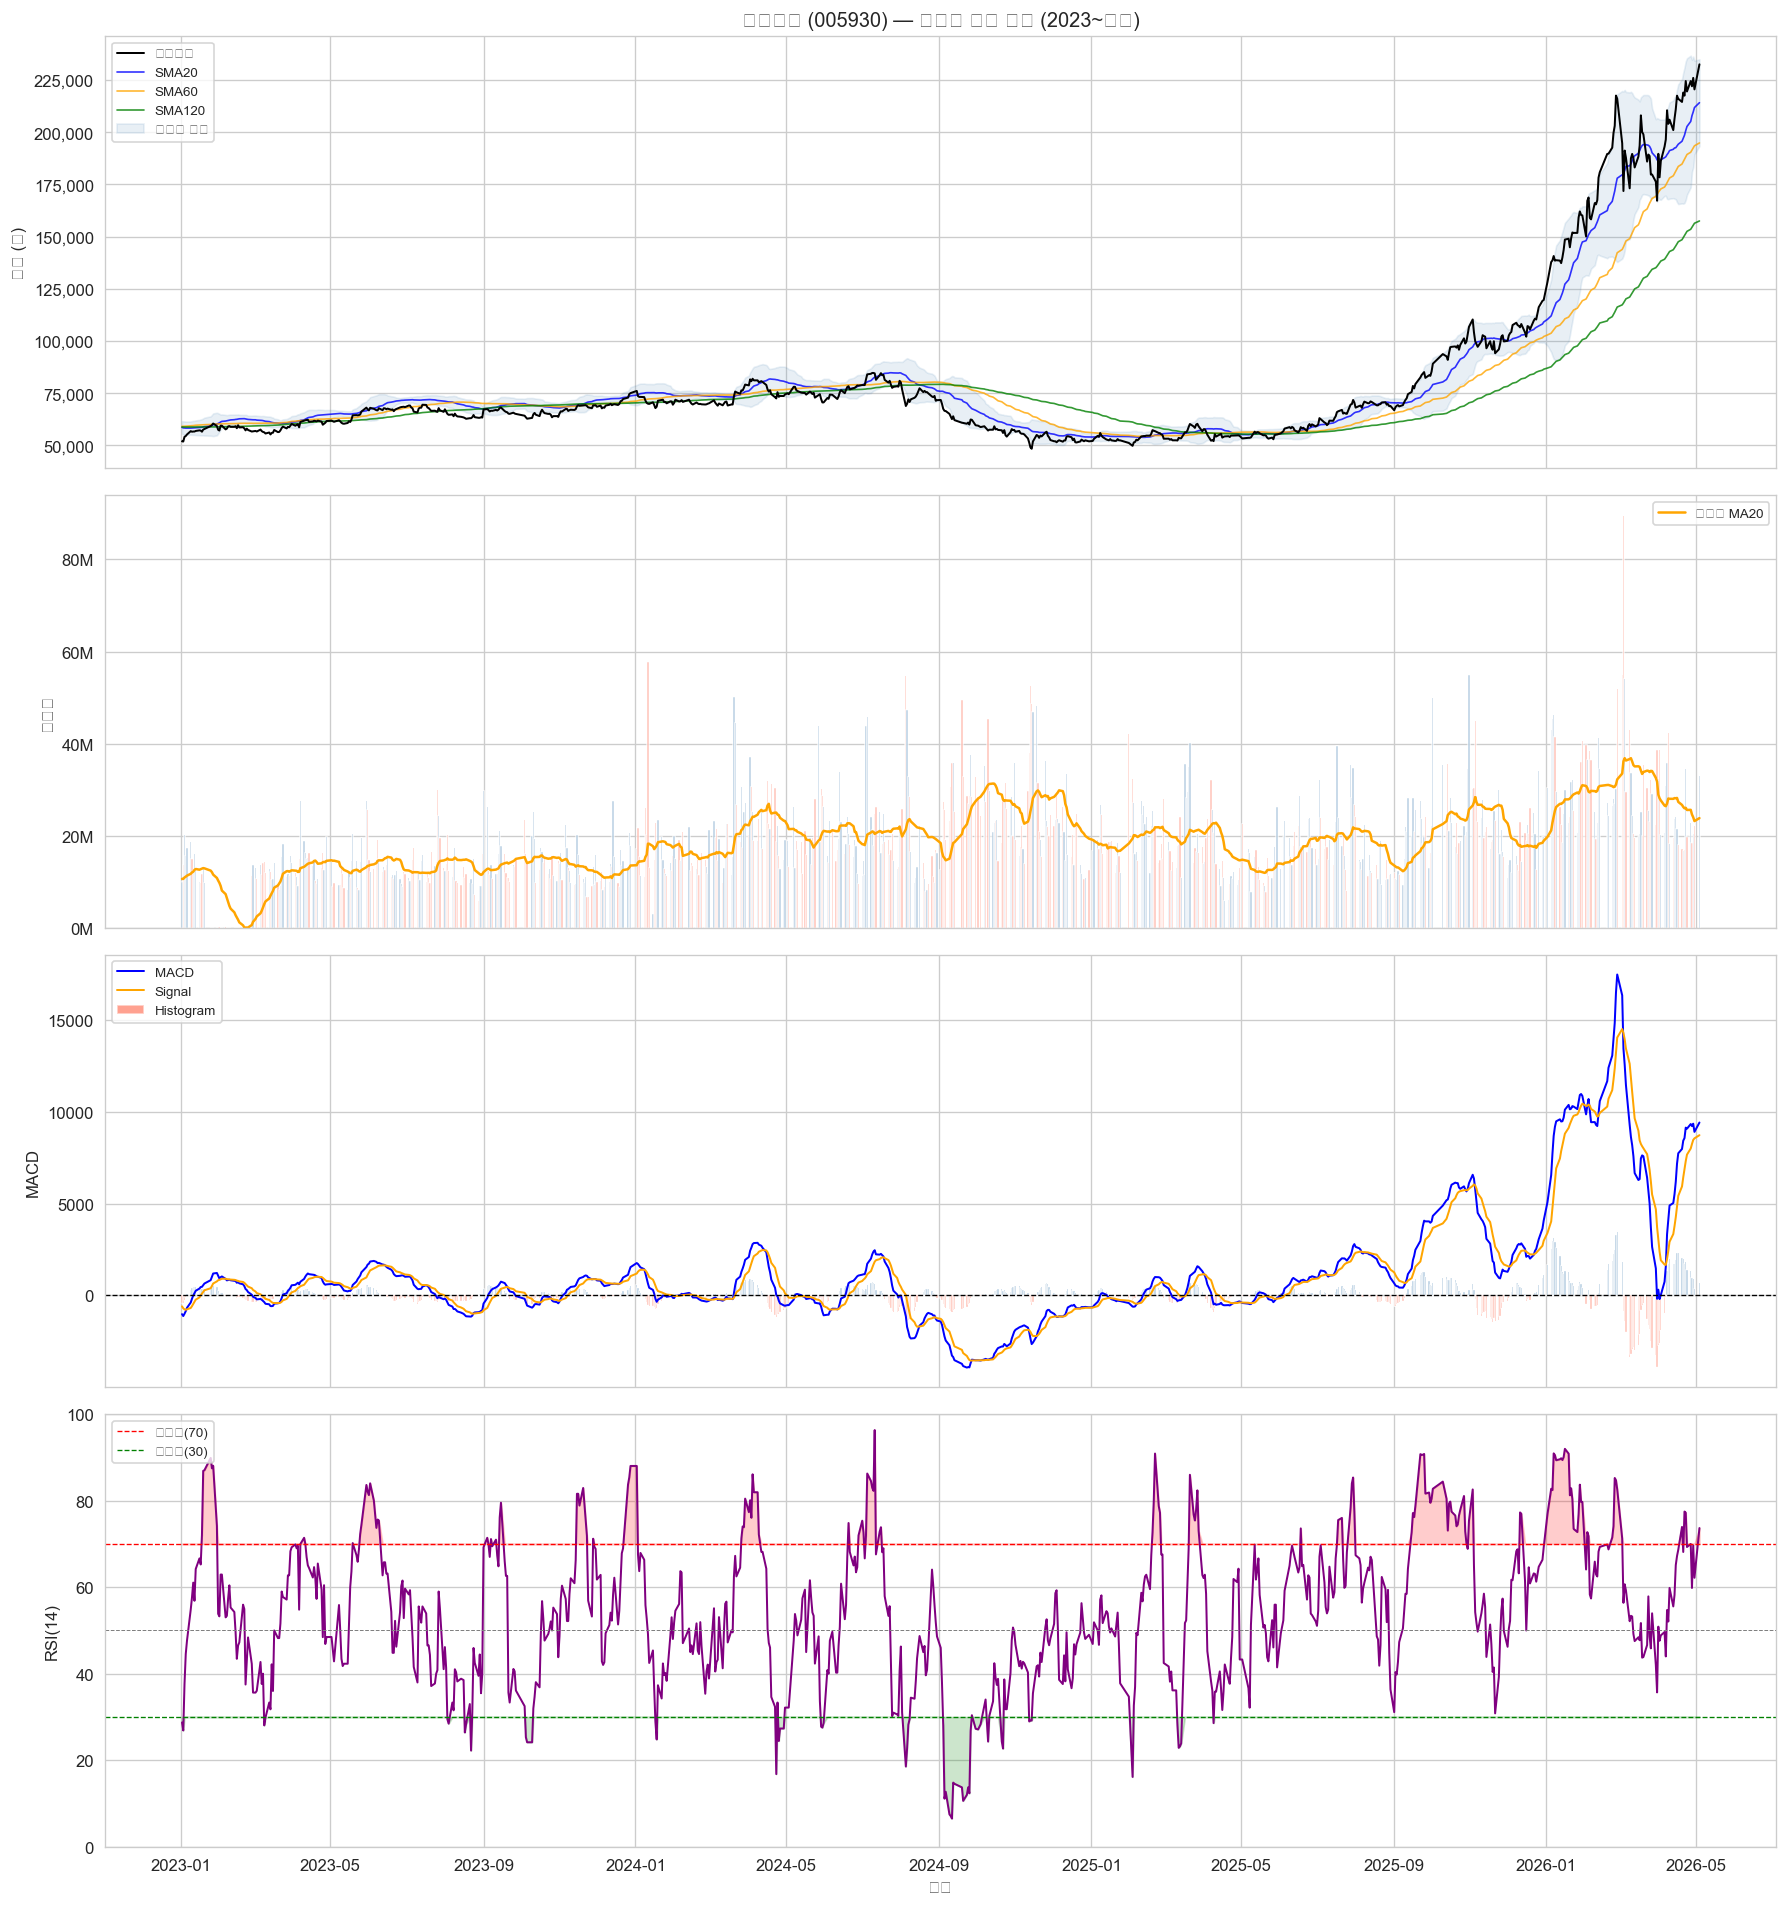

In [18]:
# 종합 기술적 지표 차트 (4패널)
fig, axes = plt.subplots(4, 1, figsize=(15, 16), sharex=True)
name = df_s['종목명'].iloc[0]

# 패널 1: 종가 + 이동평균 + 볼린저 밴드
ax = axes[0]
ax.plot(df_plot['Date'], df_plot['Adj_Close'], color='black', lw=1.2, label='수정종가', zorder=3)
ax.plot(df_plot['Date'], df_plot['SMA_20'],  color='blue',   lw=1, label='SMA20',  alpha=0.8)
ax.plot(df_plot['Date'], df_plot['SMA_60'],  color='orange', lw=1, label='SMA60',  alpha=0.8)
ax.plot(df_plot['Date'], df_plot['SMA_120'], color='green',  lw=1, label='SMA120', alpha=0.8)
ax.fill_between(df_plot['Date'], df_plot['BB_upper'], df_plot['BB_lower'],
                alpha=0.12, color='steelblue', label='볼린저 밴드')
ax.set_ylabel('가격 (원)')
ax.set_title(f'{name} ({sample_code}) — 기술적 지표 종합 (2023~현재)')
ax.legend(loc='upper left', fontsize=8)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# 패널 2: 거래량
ax = axes[1]
colors_v = ['tomato' if r < 0 else 'steelblue' for r in df_plot['Return_1d'].fillna(0)]
ax.bar(df_plot['Date'], df_plot['Volume'], color=colors_v, alpha=0.7, width=1)
ax.plot(df_plot['Date'], df_plot['Volume_MA20'], color='orange', lw=1.5, label='거래량 MA20')
ax.set_ylabel('거래량')
ax.legend(loc='upper right', fontsize=8)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

# 패널 3: MACD
ax = axes[2]
ax.plot(df_plot['Date'], df_plot['MACD'],        color='blue',   lw=1.2, label='MACD')
ax.plot(df_plot['Date'], df_plot['MACD_signal'], color='orange', lw=1.2, label='Signal')
hist_colors = ['tomato' if v < 0 else 'steelblue' for v in df_plot['MACD_hist'].fillna(0)]
ax.bar(df_plot['Date'], df_plot['MACD_hist'], color=hist_colors, alpha=0.6, width=1, label='Histogram')
ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.set_ylabel('MACD')
ax.legend(loc='upper left', fontsize=8)

# 패널 4: RSI
ax = axes[3]
ax.plot(df_plot['Date'], df_plot['RSI_14'], color='purple', lw=1.2)
ax.axhline(70, color='red',   linestyle='--', lw=0.8, label='과매수(70)')
ax.axhline(30, color='green', linestyle='--', lw=0.8, label='과매도(30)')
ax.axhline(50, color='gray',  linestyle='--', lw=0.6)
ax.fill_between(df_plot['Date'], 70, df_plot['RSI_14'].clip(lower=70),
                alpha=0.2, color='red')
ax.fill_between(df_plot['Date'], df_plot['RSI_14'].clip(upper=30), 30,
                alpha=0.2, color='green')
ax.set_ylim(0, 100)
ax.set_ylabel('RSI(14)')
ax.set_xlabel('날짜')
ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

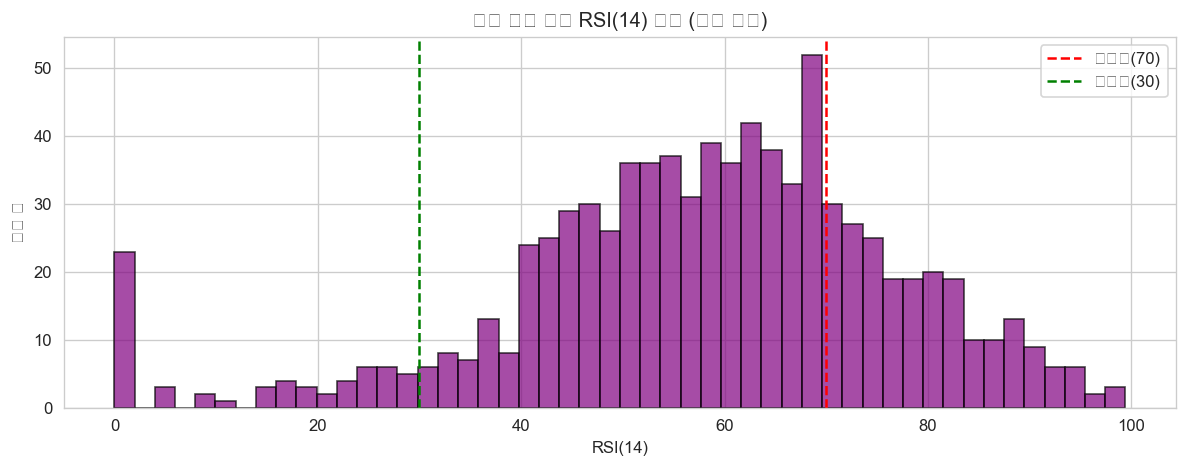

과매수(RSI>70): 211종목
과매도(RSI<30): 63종목


In [19]:
# 전체 종목 RSI 분포 (현재 시점 기준)
latest_rsi = df_all.sort_values('Date').groupby('종목코드')['RSI_14'].last().dropna()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(latest_rsi, bins=50, edgecolor='k', color='purple', alpha=0.7)
ax.axvline(70, color='red',   linestyle='--', lw=1.5, label='과매수(70)')
ax.axvline(30, color='green', linestyle='--', lw=1.5, label='과매도(30)')
ax.set_xlabel('RSI(14)')
ax.set_ylabel('종목 수')
ax.set_title(f'전체 종목 최근 RSI(14) 분포 (현재 시점)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'과매수(RSI>70): {(latest_rsi>70).sum()}종목')
print(f'과매도(RSI<30): {(latest_rsi<30).sum()}종목')

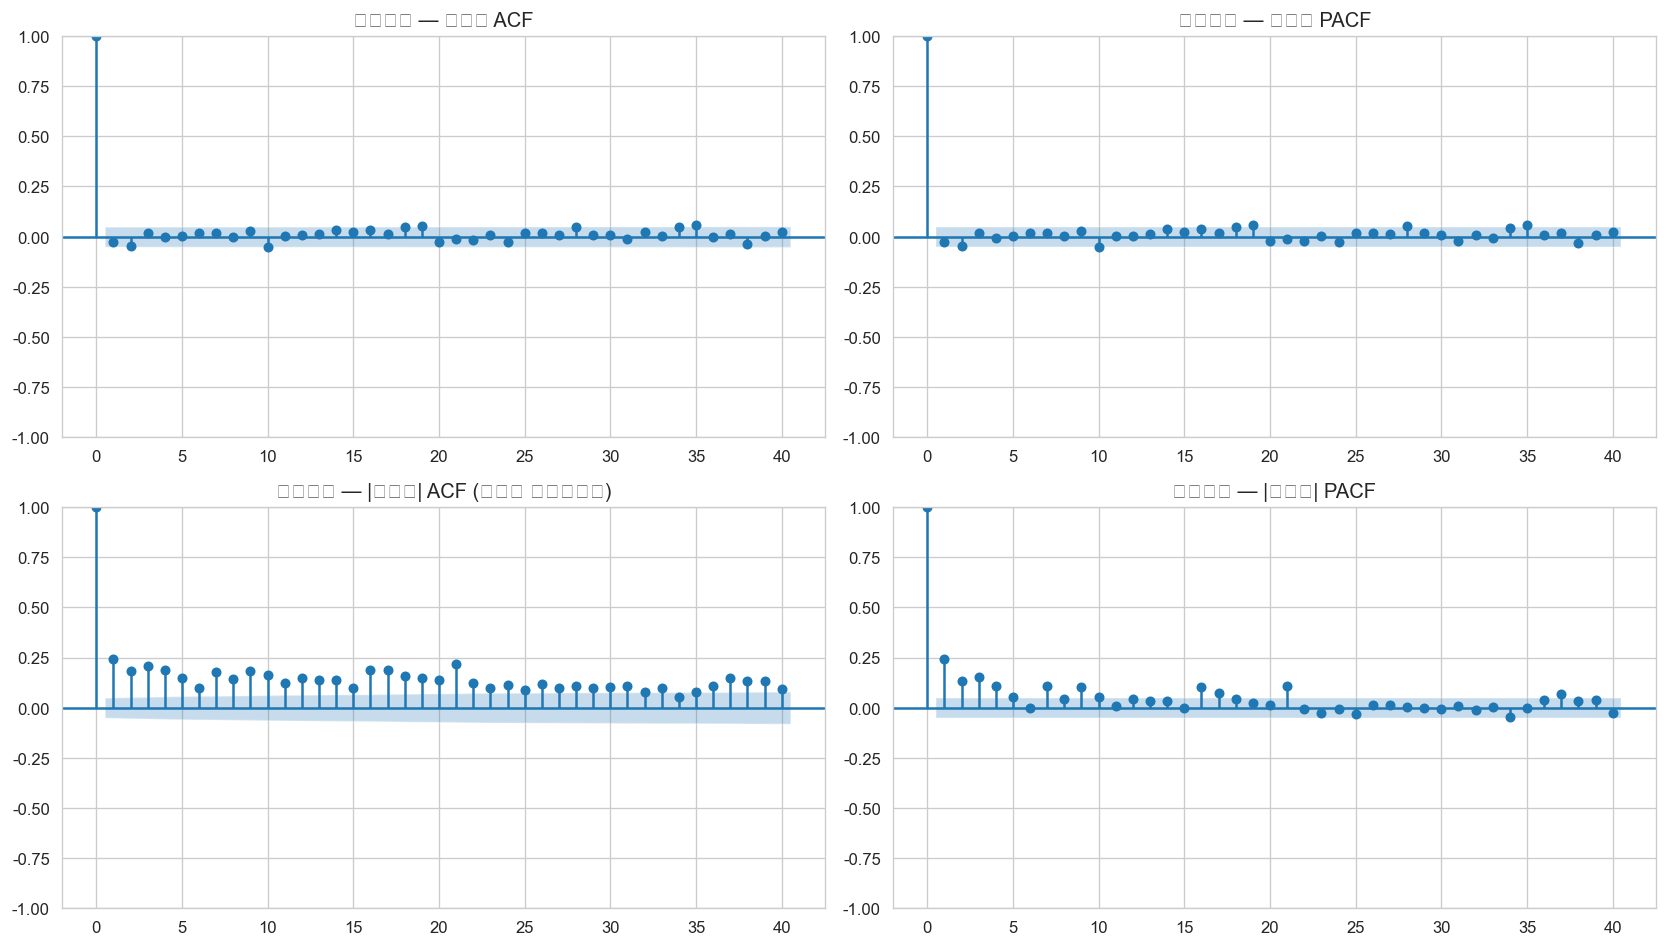

In [20]:
# 수익률 자기상관 (금융 시계열 특성 확인)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

ret_sample = df_s['Return_1d'].dropna()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_acf(ret_sample, lags=40, ax=axes[0, 0], alpha=0.05)
axes[0, 0].set_title(f'{name} — 수익률 ACF')

plot_pacf(ret_sample, lags=40, ax=axes[0, 1], alpha=0.05)
axes[0, 1].set_title(f'{name} — 수익률 PACF')

# 절댓값 수익률 (변동성 클러스터링)
plot_acf(ret_sample.abs(), lags=40, ax=axes[1, 0], alpha=0.05)
axes[1, 0].set_title(f'{name} — |수익률| ACF (변동성 클러스터링)')

plot_pacf(ret_sample.abs(), lags=40, ax=axes[1, 1], alpha=0.05)
axes[1, 1].set_title(f'{name} — |수익률| PACF')

plt.tight_layout()
plt.show()

## 6. 학습 데이터 필터링 기준 도출 & 최종 저장

In [21]:
# 필터링 기준 설정
MIN_DAYS = 500          # 최소 영업일 수 (약 2년)
MAX_VOL0_RATIO = 0.10   # 거래량=0 비율 허용 상한 (10%)
TRAIN_START = '2020-01-01'
TRAIN_END   = '2024-12-31'
TEST_START  = '2025-01-01'

# 필터 적용
valid_mask = (
    (meta['행수'] >= MIN_DAYS) &
    (meta['Volume_0_비율'] <= MAX_VOL0_RATIO)
)
meta_valid = meta[valid_mask].copy()

print(f'전체 종목: {len(meta)}')
print(f'  - 행수 < {MIN_DAYS}일 제외: {(meta["행수"] < MIN_DAYS).sum()}종목')
print(f'  - 거래량=0 비율 > {MAX_VOL0_RATIO*100:.0f}% 제외: {(meta["Volume_0_비율"] > MAX_VOL0_RATIO).sum()}종목')
print(f'유효 종목: {len(meta_valid)}')

전체 종목: 837
  - 행수 < 500일 제외: 20종목
  - 거래량=0 비율 > 10% 제외: 36종목
유효 종목: 781


In [22]:
# 유효 종목 업종 분포
print('유효 종목 업종 분포 (상위 20):')
print(meta_valid['업종'].value_counts().head(20))

유효 종목 업종 분포 (상위 20):
업종
기타 금융업                      64
자동차 신품 부품 제조업               42
의약품 제조업                     40
1차 철강 제조업                   37
기타 화학제품 제조업                 32
부동산 임대 및 공급업                24
기초 화학물질 제조업                 24
전자부품 제조업                    22
금융 지원 서비스업                  19
플라스틱제품 제조업                  17
봉제의복 제조업                    16
기타 식품 제조업                   15
특수 목적용 기계 제조업               15
종합 소매업                      13
1차 비철금속 제조업                 12
기타 전문 도매업                   11
토목 건설업                      11
시멘트, 석회, 플라스터 및 그 제품 제조업    11
보험업                         10
일반 목적용 기계 제조업                9
Name: count, dtype: int64


In [23]:
# 학습/검증/테스트 분할 요약
df_valid = df_all[df_all['종목코드'].isin(meta_valid['종목코드'])].copy()

train_df = df_valid[df_valid['Date'] <  TEST_START]
test_df  = df_valid[df_valid['Date'] >= TEST_START]

# train 내 80/20 분할
unique_dates_train = sorted(train_df['Date'].unique())
split_idx = int(len(unique_dates_train) * 0.8)
val_start = unique_dates_train[split_idx]

pure_train = train_df[train_df['Date'] < val_start]
val_df     = train_df[train_df['Date'] >= val_start]

print('── 데이터 분할 요약 ──')
print(f'학습:   {pure_train["Date"].min().date()} ~ {pure_train["Date"].max().date()} '
      f'| {len(pure_train):>9,} 행 | {pure_train["종목코드"].nunique()} 종목')
print(f'검증:   {val_df["Date"].min().date()}    ~ {val_df["Date"].max().date()} '
      f'| {len(val_df):>9,} 행 | {val_df["종목코드"].nunique()} 종목')
print(f'테스트: {test_df["Date"].min().date()}    ~ {test_df["Date"].max().date()} '
      f'| {len(test_df):>9,} 행 | {test_df["종목코드"].nunique()} 종목')

── 데이터 분할 요약 ──
학습:   2020-01-02 ~ 2023-12-26 |   735,997 행 | 779 종목
검증:   2023-12-27    ~ 2024-12-30 |   192,016 행 | 781 종목
테스트: 2025-01-02    ~ 2026-05-04 |   252,258 행 | 781 종목


In [24]:
# 타겟 레이블 생성 (다음 N일 방향성)
# Return_1d 기준 next-day direction: 1(상승), 0(하락/보합)
df_valid = df_valid.sort_values(['종목코드', 'Date']).copy()
df_valid['Target_1d']  = df_valid.groupby('종목코드')['Return_1d'].shift(-1).gt(0).astype(int)
df_valid['Target_5d']  = df_valid.groupby('종목코드')['Return_5d'].shift(-5).gt(0).astype(int)
df_valid['RetTarget_1d'] = df_valid.groupby('종목코드')['Return_1d'].shift(-1)  # 회귀 타겟

pos_rate = df_valid['Target_1d'].mean()
print(f'1일 방향성 레이블 — 상승 비율: {pos_rate:.3f} ({pos_rate*100:.1f}%)')
print(f'5일 방향성 레이블 — 상승 비율: {df_valid["Target_5d"].mean():.3f}')

1일 방향성 레이블 — 상승 비율: 0.451 (45.1%)
5일 방향성 레이블 — 상승 비율: 0.473


In [25]:
# 유효 종목 목록 저장
meta_valid[['종목코드', '종목명', '업종', '행수', '시작일', '종료일']].to_csv(
    'data/valid_stocks.csv', index=False, encoding='utf-8-sig'
)

# 타겟 포함 전체 데이터 저장
df_valid.to_parquet('data/kospi_valid.parquet', index=False)

print('저장 완료:')
print(f'  data/valid_stocks.csv     — {len(meta_valid)} 종목')
print(f'  data/kospi_valid.parquet  — {len(df_valid):,} 행')

저장 완료:
  data/valid_stocks.csv     — 781 종목
  data/kospi_valid.parquet  — 1,180,271 행


## 요약

| 항목 | 값 |
|------|----|
| 전체 수집 종목 | ~837 |
| 유효 종목 (필터 후) | - |
| 학습 기간 | 2020-01-01 ~ test_start 80% |
| 검증 기간 | train 나머지 20% |
| 테스트 기간 | 2025-01-01 ~ 현재 |
| 타겟 | 1일/5일 방향성, 1일 수익률 |

### 다음 단계 (6월)
- `kospi_valid.parquet` 로 FFT / DWT 주파수 도메인 특징 추출
- RevIN 정규화 적용 후 패치(5일) 단위 시퀀스 생성
- LightGBM baseline으로 기술적 지표 feature importance 확인